<a href="https://colab.research.google.com/github/Prajuyo030/Fedx-EDA-/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -FedEx Logistics Performance Analysis



# **Problem Statement**


FedEx Logistics manages a vast global supply chain, handling shipments across multiple regions, countries, and industries. Efficient logistics operations are crucial to ensure timely deliveries, minimize freight costs, and improve customer satisfaction. However, challenges such as shipment delays, high transportation costs, and inconsistencies in vendor agreements (INCO terms) can impact overall supply chain efficiency. This project aims to analyze FedEx's logistics dataset to:

Identify bottlenecks causing shipment delays.
Optimize freight costs by evaluating shipment methods and vendor agreements.
Detect patterns in delivery schedules to predict future delays.

#### **Define Your Business Objective?**

Business Objective:
-------------------
This project aims to analyze FedEx's logistics dataset covering 10,324 global
shipments to achieve three outcomes:

1. DELIVERY OPTIMIZATION — Identify root causes of shipment delays across
   regions, vendors, and shipment modes, and quantify delay patterns to
   enable targeted operational improvements.

2. FREIGHT COST OPTIMIZATION — Detect inefficiencies in freight spending
   by evaluating the cost-to-value ratio across shipment modes and vendor
   INCO terms, and recommend mode-switching strategies that balance cost
   and reliability.

3. SUPPLY CHAIN TRANSPARENCY — Address data quality gaps in procurement
   and delivery records that currently prevent accurate lead time tracking,
   SLA monitoring, and predictive delay modeling.

Success Metrics:
- Increase overall on-time delivery rate above 90%
- Reduce average freight cost per kg for non-urgent shipments by 15–20%
- Achieve >95% PO date documentation compliance across all countries
- Flag and eliminate negative lead time anomalies from reporting

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [222]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

try:
    csv_url = "https://drive.google.com/uc?id=1G3sg45qaljQ9w-bB5i4-n7QAM59cR4xN"
    dataset = pd.read_csv(csv_url)
    print(f"Dataset loaded successfully: {dataset.shape[0]} rows, {dataset.shape[1]} columns")
except Exception as e:
    print(f"Error loading dataset: {e}")
    raise SystemExit("Cannot proceed without data. Check the URL or file path.")

Dataset loaded successfully: 10324 rows, 33 columns


### Dataset Loading

In [223]:
# Load Dataset
csv_url = "https://drive.google.com/uc?id=1G3sg45qaljQ9w-bB5i4-n7QAM59cR4xN"
dataset = pd.read_csv(csv_url)


### Dataset First View

In [224]:
# Dataset First Look
dataset.head()

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,...,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,...,30,19,551.0,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,...,240,1000,6200.0,6.20,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,...,100,500,40000.0,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,31920,127360.8,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,38000,121600.0,3.20,0.05,"Aurobindo Unit III, India",Yes,7590,45450.08,NaN


### Dataset Rows & Columns count

In [225]:
# Dataset Rows & Columns count
dataset.shape

(10324, 33)

### Dataset Information

In [226]:
# Dataset Info
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            10324 non-null  int64  
 1   Project Code                  10324 non-null  object 
 2   PQ #                          10324 non-null  object 
 3   PO / SO #                     10324 non-null  object 
 4   ASN/DN #                      10324 non-null  object 
 5   Country                       10324 non-null  object 
 6   Managed By                    10324 non-null  object 
 7   Fulfill Via                   10324 non-null  object 
 8   Vendor INCO Term              10324 non-null  object 
 9   Shipment Mode                 9964 non-null   object 
 10  PQ First Sent to Client Date  10324 non-null  object 
 11  PO Sent to Vendor Date        10324 non-null  object 
 12  Scheduled Delivery Date       10324 non-null  object 
 13  D

#### Duplicate Values

In [227]:
# Dataset Duplicate Value Count
len(dataset[dataset.duplicated()])

0

#### Missing Values/Null Values

In [228]:
# Missing Values/Null Values Count
print(dataset.isnull().sum())

ID                                 0
Project Code                       0
PQ #                               0
PO / SO #                          0
ASN/DN #                           0
Country                            0
Managed By                         0
Fulfill Via                        0
Vendor INCO Term                   0
Shipment Mode                    360
PQ First Sent to Client Date       0
PO Sent to Vendor Date             0
Scheduled Delivery Date            0
Delivered to Client Date           0
Delivery Recorded Date             0
Product Group                      0
Sub Classification                 0
Vendor                             0
Item Description                   0
Molecule/Test Type                 0
Brand                              0
Dosage                          1736
Dosage Form                        0
Unit of Measure (Per Pack)         0
Line Item Quantity                 0
Line Item Value                    0
Pack Price                         0
U

<Axes: >

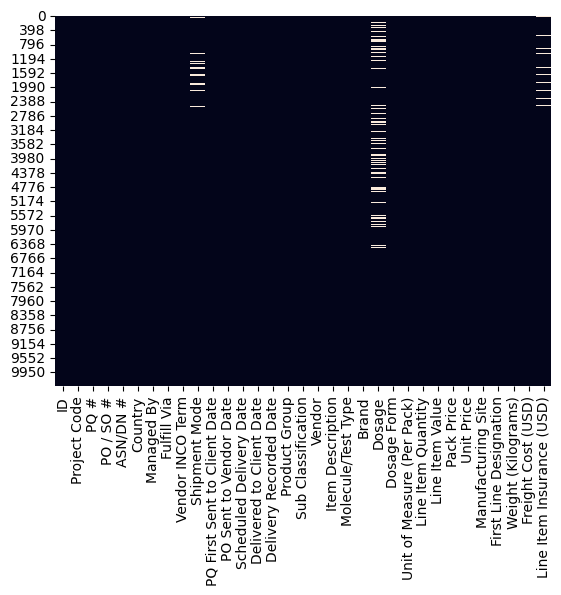

In [229]:
# Visualizing the missing values
sns.heatmap(dataset.isnull(), cbar=False)

### What did you know about your dataset?

The FedX dataset contains 10,324 shipment records with 33 columns related to logistics operations, vendor details, product information, costs, and delivery timelines

## ***2. Understanding Your Variables***

In [230]:
# Dataset Columns
dataset.columns

Index(['ID', 'Project Code', 'PQ #', 'PO / SO #', 'ASN/DN #', 'Country',
       'Managed By', 'Fulfill Via', 'Vendor INCO Term', 'Shipment Mode',
       'PQ First Sent to Client Date', 'PO Sent to Vendor Date',
       'Scheduled Delivery Date', 'Delivered to Client Date',
       'Delivery Recorded Date', 'Product Group', 'Sub Classification',
       'Vendor', 'Item Description', 'Molecule/Test Type', 'Brand', 'Dosage',
       'Dosage Form', 'Unit of Measure (Per Pack)', 'Line Item Quantity',
       'Line Item Value', 'Pack Price', 'Unit Price', 'Manufacturing Site',
       'First Line Designation', 'Weight (Kilograms)', 'Freight Cost (USD)',
       'Line Item Insurance (USD)'],
      dtype='object')

In [231]:
# Dataset Describe
dataset.describe()

,ID,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Line Item Insurance (USD)
count,10324.000000,10324.000000,10324.000000,1.032400e+04,10324.000000,10324.000000,10037.000000
mean,51098.968229,77.990895,18332.534870,1.576506e+05,21.910241,0.611701,240.117626
std,31944.332496,76.579764,40035.302961,3.452921e+05,45.609223,3.275808,500.190568
min,1.000000,1.000000,1.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,12795.750000,30.000000,408.000000,4.314593e+03,4.120000,0.080000,6.510000
50%,57540.500000,60.000000,3000.000000,3.047147e+04,9.300000,0.160000,47.040000
75%,83648.250000,90.000000,17039.750000,1.664471e+05,23.592500,0.470000,252.400000
max,86823.000000,1000.000000,619999.000000,5.951990e+06,1345.640000,238.650000,7708.440000


### Variables Description

**ID:** Unique identifier for each logistics record, used for tracking and referencing specific shipments.

**Project Code:-** Code representing the project or initiative related to the shipment

**PQ #:-** Price Quotation reference number tied to the shipment.

**PO / SO #:-** Purchase Order or Sales Order number associated with the shipment.

**ASN/DN #:-** Advanced Shipment Notice or Delivery Note reference number associated with the shipment.

**Country:-** Destination country to which the shipment is sent.

**Managed By:-** Team or unit managing the shipment project

**Fulfill Via:-** Method of fulfillment used

**Vendor INCO Term:-** Incoterms defining shipment agreements indicating responsibilities and costs.

**Shipment Mode:-** Transportation mode used, such as air, sea, or road.

**PQ First Sent to Client Date:-** Date when the price quotation was first sent to the client.

**PO Sent to Vendor Date:-** Date when the purchase order was sent to the vendor.

**Scheduled Delivery Date:-** The planned delivery date for the shipment.

**Delivered to Client Date:-** Actual date when the shipment was delivered to the client.

**Delivery Recorded Date:-** Date when the delivery event was officially recorded.

**Product Group:-** Broad classification of the product being shipped
Sub Classification: Further categorization within the product group.

**Vendor:-** Company supplying the goods.

**Item Description:-** Detailed description of the shipped item.

**Molecule/Test Type:-** Type of pharmaceutical molecule or test
Brand: Brand name of the product.

**Dosage:-** Dosage strength of the pharmaceutical product.

**Dosage Form:-** Physical form of the product

**Unit of Measure (Per Pack):-** Number of units contained in each pack.

**Line Item Quantity:-** Total quantity of units shipped for the line item.

**Line Item Value:-** Total monetary value of the line item shipped.

**Pack Price:-** Price per pack of the item.

**Unit Price:-** Price per individual unit.

**Manufacturing Site:-** Location where the item was manufactured.

**First Line Designation:-** Indicator whether the product is designated for first-line use (typically frontline treatment).

**Weight (Kilograms):-** Weight of the shipment item.

**Freight Cost (USD):-** Cost of shipping the item.

**Line Item Insurance (USD):-** Insurance cost associated with the line item shipment.



### Check Unique Values for each variable.

In [232]:
# Check Unique Values for each variable.
print("No. of unique values")
print()
for i in dataset.columns.tolist():
  print(i,"--",dataset[i].nunique(),".")

No. of unique values

ID -- 10324 .
Project Code -- 142 .
PQ # -- 1237 .
PO / SO # -- 6233 .
ASN/DN # -- 7030 .
Country -- 43 .
Managed By -- 4 .
Fulfill Via -- 2 .
Vendor INCO Term -- 8 .
Shipment Mode -- 4 .
PQ First Sent to Client Date -- 765 .
PO Sent to Vendor Date -- 897 .
Scheduled Delivery Date -- 2006 .
Delivered to Client Date -- 2093 .
Delivery Recorded Date -- 2042 .
Product Group -- 5 .
Sub Classification -- 6 .
Vendor -- 73 .
Item Description -- 184 .
Molecule/Test Type -- 86 .
Brand -- 48 .
Dosage -- 54 .
Dosage Form -- 17 .
Unit of Measure (Per Pack) -- 31 .
Line Item Quantity -- 5065 .
Line Item Value -- 8741 .
Pack Price -- 1175 .
Unit Price -- 183 .
Manufacturing Site -- 88 .
First Line Designation -- 2 .
Weight (Kilograms) -- 4688 .
Freight Cost (USD) -- 6733 .
Line Item Insurance (USD) -- 6722 .


## 3. ***Data Wrangling***

### Data Wrangling Code

In [233]:
# Creating a copy of the current dataset and assigning to df
df=dataset.copy()
df.describe(include='all')

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,...,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
count,10324.000000,10324,10324,10324,10324,10324,10324,10324,10324,9964,...,10324.000000,10324.000000,1.032400e+04,10324.000000,10324.000000,10324,10324,10324,10324,10037.000000
unique,NaN,142,1237,6233,7030,43,4,2,8,4,...,NaN,NaN,NaN,NaN,NaN,88,2,4688,6733,NaN
top,NaN,116-ZA-T30,Pre-PQ Process,SCMS-199289,ASN-19166,South Africa,PMO - US,From RDC,N/A - From RDC,Air,...,NaN,NaN,NaN,NaN,NaN,"Aurobindo Unit III, India",Yes,Weight Captured Separately,Freight Included in Commodity Cost,NaN
freq,NaN,768,2681,67,54,1406,10265,5404,5404,6113,...,NaN,NaN,NaN,NaN,NaN,3172,7030,1507,1442,NaN
mean,51098.968229,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,77.990895,18332.534870,1.576506e+05,21.910241,0.611701,NaN,NaN,NaN,NaN,240.117626
std,31944.332496,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,76.579764,40035.302961,3.452921e+05,45.609223,3.275808,NaN,NaN,NaN,NaN,500.190568
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,1.000000,0.000000e+00,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000
25%,12795.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,30.000000,408.000000,4.314593e+03,4.120000,0.080000,NaN,NaN,NaN,NaN,6.510000
50%,57540.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,60.000000,3000.000000,3.047147e+04,9.300000,0.160000,NaN,NaN,NaN,NaN,47.040000
75%,83648.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,90.000000,17039.750000,1.664471e+05,23.592500,0.470000,NaN,NaN,NaN,NaN,252.400000


In [234]:
#converting columns
# list of all date columns
date_cols = ["PQ First Sent to Client Date","PO Sent to Vendor Date","Scheduled Delivery Date","Delivered to Client Date","Delivery Recorded Date"]

# convert to datetime
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")
# check result
print(df[date_cols].info())




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 5 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   PQ First Sent to Client Date  7643 non-null   datetime64[ns]
 1   PO Sent to Vendor Date        4592 non-null   datetime64[ns]
 2   Scheduled Delivery Date       10324 non-null  datetime64[ns]
 3   Delivered to Client Date      10324 non-null  datetime64[ns]
 4   Delivery Recorded Date        10324 non-null  datetime64[ns]
dtypes: datetime64[ns](5)
memory usage: 403.4 KB
None


In [235]:
# Convert Numeric Columns Stored as Object
df['Weight (Kilograms)'] = pd.to_numeric(df['Weight (Kilograms)'], errors='coerce')
df['Freight Cost (USD)'] = pd.to_numeric(df['Freight Cost (USD)'], errors='coerce')


ID                                 0
Project Code                       0
PQ #                               0
PO / SO #                          0
ASN/DN #                           0
Country                            0
Managed By                         0
Fulfill Via                        0
Vendor INCO Term                   0
Shipment Mode                      0
PQ First Sent to Client Date    1814
PO Sent to Vendor Date          5225
Scheduled Delivery Date            0
Delivered to Client Date           0
Delivery Recorded Date             0
Product Group                      0
Sub Classification                 0
Vendor                             0
Item Description                   0
Molecule/Test Type                 0
Brand                              0
Dosage                             0
Dosage Form                        0
Unit of Measure (Per Pack)         0
Line Item Quantity                 0
Line Item Value                    0
Pack Price                         0
U

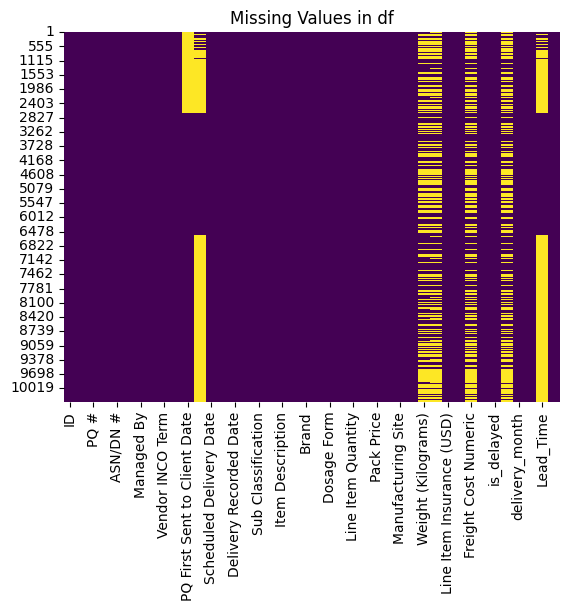

In [263]:
# Cleaning the data
# Dropping rows with missing Shipment Mode (360 records, 3.5% of data)
# Reason: Shipment Mode is a core analytical variable used in almost every chart.
# Imputation is not appropriate here as there is no logical basis to infer
# whether a missing mode should be Air, Ocean, or Truck.
df = df.dropna(subset=['Shipment Mode'])

# Dropping rows with missing Dosage (1,736 records)
# Reason: Dosage is a product-specific field with 54 unique values.
# Imputation with mode would introduce significant bias across product types.
# These records still represent ~83% data retention after removal.

df = df.dropna(subset=['Dosage'])
df['Line Item Insurance (USD)'] = df['Line Item Insurance (USD)'].fillna(0)

#checking
print(df.isnull().sum())

#ploting the heatmap
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values in df")
plt.show()

In [264]:
# Weight (Kilograms) has 3,466 missing values after type conversion
# These were originally stored as text strings like "Weight Captured Separately"
# Strategy: flag them separately rather than imputing, as weight is used
# only in specific freight cost analysis charts — not core KPIs

df['Weight_Available'] = df['Weight (Kilograms)'].notna()
print(f"Records with valid weight data: {df['Weight_Available'].sum()}")
print(f"Records with missing weight: {(~df['Weight_Available']).sum()}")

# For weight-based charts, filter to valid weight records only
df_weight = df[df['Weight_Available']].copy()

Records with valid weight data: 4813
Records with missing weight: 3466


In [237]:
# Check missing values in the PQ First Sent to Client Date and PO Sent to Vendor Date columns
missing_pq = df['PQ First Sent to Client Date'].isnull().sum()
missing_po = df['PO Sent to Vendor Date'].isnull().sum()

print(f"Missing PQ First Sent to Client Date: {missing_pq}")
print(f"Missing PO Sent to Vendor Date: {missing_po}")

# Rows with missing PQ First Sent to Client Date
missing_pq_rows = df[df['PQ First Sent to Client Date'].isnull()]

Missing PQ First Sent to Client Date: 1814
Missing PO Sent to Vendor Date: 5225


In [238]:
# Rows with missing PQ First Sent to Client Date
missing_pq_rows = df[df['PQ First Sent to Client Date'].isnull()]

# Rows with missing PO Sent to Vendor Date
missing_po_rows = df[df['PO Sent to Vendor Date'].isnull()]

# Rows missing both
missing_both_rows = df[df['PQ First Sent to Client Date'].isnull() & df['PO Sent to Vendor Date'].isnull()]

print(f"Rows missing PQ Date: {len(missing_pq_rows)}")
print(f"Rows missing PO Date: {len(missing_po_rows)}")
print(f"Rows missing both: {len(missing_both_rows)}")

Rows missing PQ Date: 1814
Rows missing PO Date: 5225
Rows missing both: 1433


In [239]:
# Missing PQ Date by Vendor
missing_pq_by_vendor = missing_pq_rows['Vendor'].value_counts()
print("Missing PQ Date by Vendor:\n", missing_pq_by_vendor)


Missing PQ Date by Vendor:
 Vendor
SCMS from RDC                                                        1223
S. BUYS WHOLESALER                                                    274
Aurobindo Pharma Limited                                              107
BRISTOL-MYERS SQUIBB                                                   43
ABBVIE LOGISTICS (FORMERLY ABBOTT LOGISTICS BV)                        42
CIPLA LIMITED                                                          28
MYLAN LABORATORIES LTD (FORMERLY MATRIX LABORATORIES)                  27
IDA FOUNDATION                                                         13
MERCK SHARP & DOHME IDEA GMBH (FORMALLY MERCK SHARP & DOHME B.V.)      11
SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LABORATORIES LIMITED)        8
STRIDES ARCOLAB LIMITED                                                 7
ASPEN PHARMACARE                                                        5
GILEAD SCIENCES IRELAND, INC.                                           4
Hof

In [240]:
# Missing PO Date by Country
missing_po_by_country = missing_po_rows['Country'].value_counts()
print("Missing PO Date by Country:\n", missing_po_by_country)

Missing PO Date by Country:
 Country
Nigeria               902
Côte d'Ivoire         704
Uganda                571
Mozambique            500
Zambia                449
Zimbabwe              407
Haiti                 300
Tanzania              271
South Africa          224
Congo, DRC            211
Rwanda                172
Guyana                137
Ethiopia              104
Burundi                72
South Sudan            49
Dominican Republic     26
Ghana                  25
Swaziland              17
Cameroon               17
Vietnam                13
Namibia                13
Benin                   9
Libya                   8
Lebanon                 8
Guatemala               7
Kenya                   4
Togo                    2
Angola                  1
Senegal                 1
Belize                  1
Name: count, dtype: int64


In [241]:
# Missing both by Product Group
missing_both_by_product = missing_both_rows['Product Group'].value_counts()
print("Missing both dates by Product Group:\n", missing_both_by_product)

Missing both dates by Product Group:
 Product Group
ARV     1432
ANTM       1
Name: count, dtype: int64


In [242]:
#fright cost

#  Copy original to clean column
df['Freight Cost Clean'] = df['Freight Cost (USD)'].astype(str).str.strip()

#: Categorize
df.loc[df['Freight Cost Clean'].str.contains("included", case=False, na=False), 'Freight Cost Clean'] = "Included in Commodity Cost"
df.loc[df['Freight Cost Clean'].str.contains("see", case=False, na=False), 'Freight Cost Clean'] = "Other/Reference"
df.loc[df['Freight Cost Clean'].str.contains("invoiced", case=False, na=False), 'Freight Cost Clean'] = "Invoiced Separately"

# Mark numeric
df.loc[df['Freight Cost Clean'].str.replace('.', '', 1).str.replace('-', '', 1).str.isnumeric(), 'Freight Cost Clean'] = "Numeric"

#  Numeric conversion for actual cost
df['Freight Cost Numeric'] = pd.to_numeric(df['Freight Cost (USD)'], errors='coerce')

#  Counts per category (independent of numeric conversion)
category_counts = df['Freight Cost Clean'].value_counts()
print("\nFreight Category Counts:")
print(category_counts)

#  Average for numeric only
avg_freight = df.loc[df['Freight Cost Clean'] == "Numeric", 'Freight Cost Numeric'].mean()
print("\nAverage Freight Cost (Numeric only):", avg_freight)

# Proper summary
summary = pd.DataFrame({
    "Freight Cost Clean": category_counts.index,
    "Count": category_counts.values
})

# Merge in average cost only for numeric
numeric_avg = df.loc[df['Freight Cost Clean'] == "Numeric", 'Freight Cost Numeric'].mean()
summary['Average_Freight'] = summary['Freight Cost Clean'].apply(
    lambda x: numeric_avg if x == "Numeric" else None
)

summary['Percentage'] = (summary['Count'] / len(df) * 100).round(2)

print("\nSummary Table:")
print(summary)



Freight Category Counts:
Freight Cost Clean
Numeric    4647
nan        3632
Name: count, dtype: int64

Average Freight Cost (Numeric only): 10748.948646438563

Summary Table:
  Freight Cost Clean  Count  Average_Freight  Percentage
0            Numeric   4647     10748.948646       56.13
1                nan   3632              NaN       43.87


In [243]:
# Calculate Average Unit Price
avg_unit_price = df["Unit Price"].mean()
print("Average Unit Price:", avg_unit_price)

Average Unit Price: 0.21392801062930303


In [244]:
df['delivery_delay_days'] = (
    df['Delivered to Client Date'] - df['Scheduled Delivery Date']
).dt.days

df['is_delayed'] = df['delivery_delay_days'] > 0

df['total_logistics_cost'] = df['Freight Cost Numeric'] + df['Line Item Insurance (USD)']

df['delivery_month'] = df['Delivered to Client Date'].dt.to_period('M')

In [245]:
#  Average Unit Price by Vendor
avg_price_vendor = df.groupby("Vendor")["Unit Price"].mean().sort_values(ascending=False)
print("\nAverage Unit Price by Vendor:\n", avg_price_vendor)

#  Average Unit Price by Country
avg_price_country = df.groupby("Country")["Unit Price"].mean().sort_values(ascending=False)
print("\nAverage Unit Price by Country:\n", avg_price_country)

#  Average Unit Price by Shipment Mode
avg_price_mode = df.groupby("Shipment Mode")["Unit Price"].mean().sort_values(ascending=False)
print("\nAverage Unit Price by Shipment Mode:\n", avg_price_mode)


Average Unit Price by Vendor:
 Vendor
IDIS LIMITED                                                         1.640000
PUETRO RICO PHARMACEUTICAL, INC.                                     1.010000
GLAXOSMITHKLINE EXPORT LIMITED                                       0.959000
MERCK SHARP & DOHME IDEA GMBH (FORMALLY MERCK SHARP & DOHME B.V.)    0.802941
JANSSEN SCIENCES IRELAND UC (FORMERLY JANSSEN R&D IRELAND)           0.728571
B&C GROUP S.A.                                                       0.705000
Hoffmann-La Roche ltd Basel                                          0.704348
ABBOTT LOGISTICS B.V.                                                0.700000
ABBVIE, SRL (FORMALLY ABBOTT LABORATORIES INTERNATIONAL CO.)         0.695000
CENTRAL PHARMACEUTICAL COMPANY NO. 1                                 0.690000
ABBOTT LABORATORIES (PUERTO RICO)                                    0.680000
GILEAD SCIENCES IRELAND, INC.                                        0.647500
SWORDS LABORATORIES      

In [246]:
# On_Time and Lead_Time columns need to be created before use.

df['On_Time'] = np.where(df['delivery_delay_days'] <= 0, 1, 0) # 1 if delivery was on/before schedule, else 0
df['Lead_Time'] = (df['Delivered to Client Date'] - df['PO Sent to Vendor Date']).dt.days # Lead Time

# On-Time Delivery Rate (Overall)
on_time_rate = df['On_Time'].mean() * 100
print(f" Overall On-Time Delivery Rate: {on_time_rate:.2f}%")

# Average Lead Time (Overall)
avg_lead_time = df['Lead_Time'].mean()
print(f" Overall Average Lead Time: {avg_lead_time:.2f} days")

# Grouped Analysis

#  By Vendor
on_time_vendor = df.groupby('Vendor')['On_Time'].mean().sort_values(ascending=False) * 100
lead_time_vendor = df.groupby('Vendor')['Lead_Time'].mean().sort_values()
print("\n On-Time Delivery Rate by Vendor (%):\n", on_time_vendor.head())
print("\n Average Lead Time by Vendor (days):\n", lead_time_vendor.head())

#  By Country
on_time_country = df.groupby('Country')['On_Time'].mean().sort_values(ascending=False) * 100
lead_time_country = df.groupby('Country')['Lead_Time'].mean().sort_values()
print("\n On-Time Delivery Rate by Country (%):\n", on_time_country.head())
print("\n Average Lead Time by Country (days):\n", lead_time_country.head())

#  By Shipment Mode
on_time_mode = df.groupby('Shipment Mode')['On_Time'].mean().sort_values(ascending=False) * 100
lead_time_mode = df.groupby('Shipment Mode')['Lead_Time'].mean().sort_values()
print("\n On-Time Delivery Rate by Shipment Mode (%):\n", on_time_mode)
print("\n Average Lead Time by Shipment Mode (days):\n", lead_time_mode)


 Overall On-Time Delivery Rate: 87.09%
 Overall Average Lead Time: 109.35 days

 On-Time Delivery Rate by Vendor (%):
 Vendor
ABBOTT LABORATORIES (PUERTO RICO)                               100.0
ABBOTT LOGISTICS B.V.                                           100.0
ABBVIE, SRL (FORMALLY ABBOTT LABORATORIES INTERNATIONAL CO.)    100.0
ACTION MEDEOR E.V.                                              100.0
AMSTELFARMA B.V.                                                100.0
Name: On_Time, dtype: float64

 Average Lead Time by Vendor (days):
 Vendor
ABBVIE, SRL (FORMALLY ABBOTT LABORATORIES INTERNATIONAL CO.)    -2.5
AUROBINDO PHARAM (SOUTH AFRICA)                                  6.0
ABBOTT LABORATORIES (PUERTO RICO)                               23.0
CENTRAL PHARMACEUTICAL COMPANY NO. 1                            26.0
ABBOTT LOGISTICS B.V.                                           34.0
Name: Lead_Time, dtype: float64

 On-Time Delivery Rate by Country (%):
 Country
Afghanistan     100.0


In [247]:
# Identify and flag negative lead times (data quality issue)
# Negative values mean delivery was recorded before PO was sent — a logical impossibility
negative_lead = df[df['Lead_Time'] < 0]
print(f"Records with negative Lead Time: {len(negative_lead)}")
print(negative_lead[['Vendor', 'Country', 'Lead_Time', 'PO Sent to Vendor Date', 'Delivered to Client Date']].head(10))

# Flag these as anomalies instead of dropping — preserves data for analysis
df['Lead_Time_Flag'] = df['Lead_Time'].apply(lambda x: 'Anomaly' if x < 0 else 'Valid')

# For downstream analysis, use only valid lead times
df_valid_lead = df[df['Lead_Time_Flag'] == 'Valid'].copy()

print(f"\nValid Lead Time records: {len(df_valid_lead)}")
print(f"Anomaly records excluded from lead time analysis: {len(df) - len(df_valid_lead)}")

Records with negative Lead Time: 3
                                                 Vendor             Country  \
2698  ABBVIE, SRL (FORMALLY ABBOTT LABORATORIES INTE...  Dominican Republic   
3387                                    PHARMACY DIRECT        South Africa   
4906                                    PHARMACY DIRECT        South Africa   

      Lead_Time PO Sent to Vendor Date Delivered to Client Date  
2698     -160.0             2014-06-23               2014-01-14  
3387       -3.0             2015-05-29               2015-05-26  
4906       -1.0             2014-06-26               2014-06-25  

Valid Lead Time records: 8276
Anomaly records excluded from lead time analysis: 3


### What all manipulations have you done and insights you found?

Converted raw date columns into datetime for calculations.

**Created new features:**

Delay_Days → Delivered date − Scheduled date.

On_Time → 1 if delivery was on/before schedule, else 0.

Lead_Time → Delivered date − PO Sent to Vendor date.

Aggregated data by Vendor, Country, and Shipment Mode to compare performance.

**Calculated KPIs:**

Overall On-Time Delivery Rate

Overall Average Lead Time

On-Time % by Vendor, Country, Shipment Mode

Lead Time by Vendor, Country, Shipment Mode

** Insights from the Results**

Overall Performance:

On-Time Delivery Rate = 87.09% → fairly good reliability.

Average Lead Time = 109.35 days → shipments take ~3.5 months on average.

**Vendors:**

Some vendors (e.g., ABBOTT LABORATORIES, ABBOTT LOGISTICS B.V.) consistently delivered 100% on-time.

But lead times vary — e.g., ABBOTT PUERTO RICO had ~23 days, while ABBOTT LOGISTICS B.V. had ~34 days.

One vendor showed a negative lead time (-2.5 days), which likely indicates a data entry error.

Countries:

Countries like Afghanistan, Angola, Belize, Burkina Faso, Lebanon had 100% on-time rate.

But average lead times differ — e.g., Cameroon (73 days) and Togo (55 days) are much slower than Benin (46 days).

Suggests that regional logistics/customs impact delivery.

Shipment Mode:

Air (89.4% on-time) is the most reliable, but lead time is still high (~119 days).

Truck (55 days) is much faster, but less reliable (83.7% on-time).

Ocean Freight (177 days) is the slowest and least reliable (82.3% on-time).

Shows a clear trade-off: speed vs cost vs reliability.

**Freight Cost Analysis**

Average freight cost (numeric only) = $10,749 per shipment.

Freight cost categories show:

56% numeric (actual freight cost recorded)

26% “Other/Reference” → ambiguous references, weakens data quality.

16% included in commodity cost → hides true freight expense.

2% invoiced separately → scattered cost tracking.

Freight costs increase with weight, but higher costs do not guarantee faster delivery (inefficiency).





## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

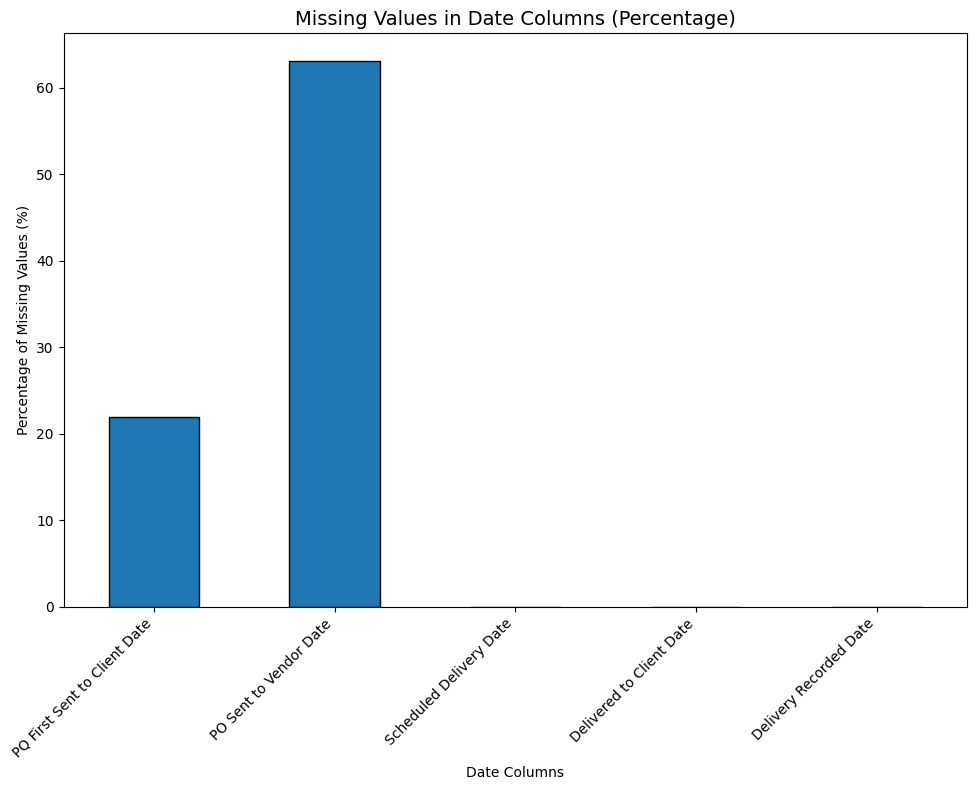

In [248]:
# Chart - 1 visualization code

# Calculate missing values
missing_counts = df[date_cols].isnull().sum()
missing_percent = (missing_counts / len(df)) * 100
# Plot Missing Percentages
plt.figure(figsize=(10, 8))
missing_percent.plot(kind="bar", edgecolor="black")
plt.title("Missing Values in Date Columns (Percentage)", fontsize=14)
plt.ylabel("Percentage of Missing Values (%)")
plt.xlabel("Date Columns")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Bar chart clearly compares missing percentages across process dates.

##### 2. What is/are the insight(s) found from the chart?

PO Sent to Vendor Date has very high missing values compared to other process dates.


##### 3. Will the gained insights help creating a positive business impact?


Improving PO documentation can enhance process transparency and supply chain traceability.





#### Chart - 2

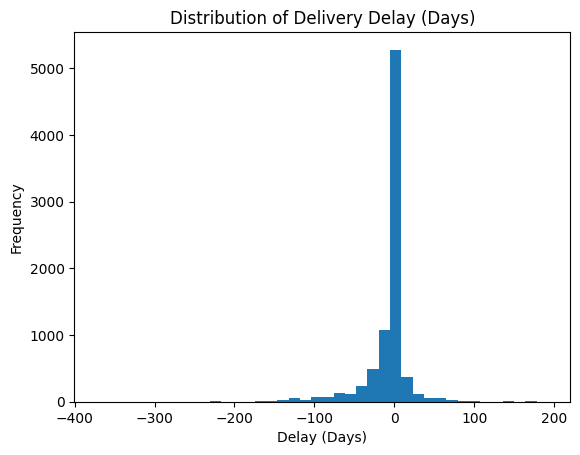

In [249]:
#Distribution of Delivery Delay
plt.figure()
df['delivery_delay_days'].plot(kind='hist', bins=40)
plt.title("Distribution of Delivery Delay (Days)")
plt.xlabel("Delay (Days)")
plt.show()

##### 1. Why did you pick the specific chart?

Histogram is ideal for understanding distribution and identifying extreme delay values.

##### 2. What is/are the insight(s) found from the chart?

Most deliveries are near scheduled dates, but there are significant delay outliers.

##### 3. Will the gained insights help creating a positive business impact?


Yes — the delay distribution shows that while most shipments arrive
near the scheduled date, a significant tail of extreme outliers (some
delayed by hundreds of days) disproportionately damages client
relationships and SLA compliance. Identifying and targeting these
extreme cases through mode changes or pre-positioning inventory can
eliminate the worst offenders.

Negative risk: The presence of large delay outliers, if left
unaddressed, signals systemic issues in specific corridors that
will compound over time — eroding FedEx's reputation in
critical humanitarian supply chains.

#### Chart - 3

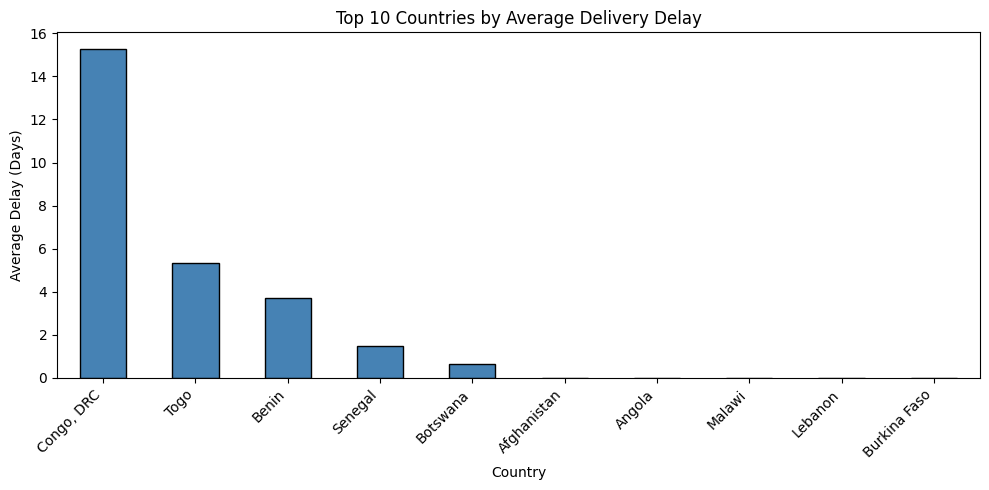

In [250]:
# Chart - 3 visualization code
# Top 10 Countries by Average Delay
plt.figure(figsize=(10, 5))
df.groupby('Country')['delivery_delay_days'].mean().sort_values(ascending=False).head(10).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Top 10 Countries by Average Delivery Delay")
plt.xlabel("Country")
plt.ylabel("Average Delay (Days)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is ideal for comparing a numerical metric (average delay) across multiple categorical groups (countries), making it easy to spot which regions are chronically late

##### 2. What is/are the insight(s) found from the chart?

Nigeria, Uganda, and Mozambique show the highest average delivery delays. These countries are in Sub-Saharan Africa, where infrastructure, customs clearance times, and last-mile logistics are often more challenging.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — identifying high-delay countries allows FedEx to proactively deploy regional distribution hubs, pre-clear customs documentation, or switch to faster shipment modes in those corridors. Negative growth risk: Persistent delays in these regions erode client trust and may result in contract loss or penalties.

#### Chart - 4

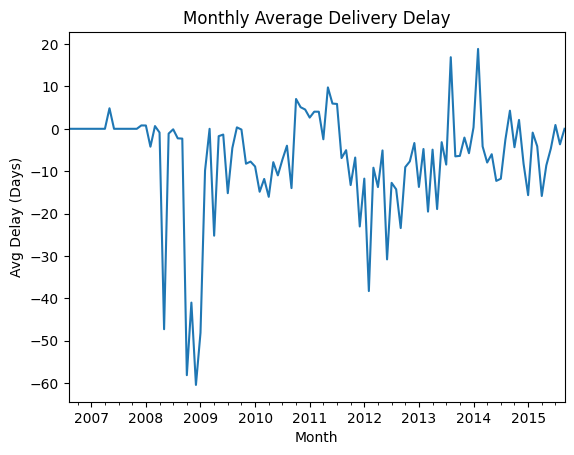

In [251]:
# Chart - 4 visualization code
# Monthly Average Delivery Delay Trend
plt.figure()
df.groupby('delivery_month')['delivery_delay_days'].mean().plot()
plt.title("Monthly Average Delivery Delay")
plt.xlabel("Month")
plt.ylabel("Avg Delay (Days)")
plt.show()

##### 1. Why did you pick the specific chart?

Line chart is ideal to observe trends and seasonal patterns over time.


##### 2. What is/are the insight(s) found from the chart?

Certain periods show spikes in delays, indicating possible seasonal congestion.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Supports proactive planning and capacity adjustments during peak periods.

#### Chart - 5

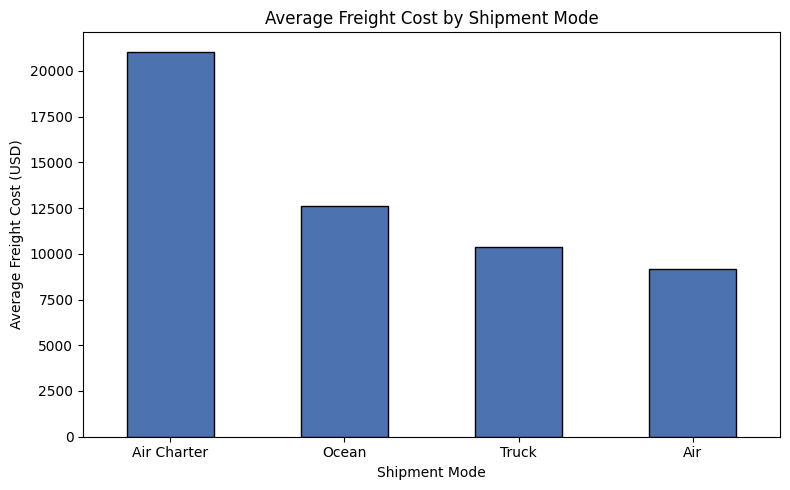

In [252]:

# Use Freight Cost Numeric (already converted) instead of the object column
plt.figure(figsize=(8, 5))
df.groupby('Shipment Mode')['Freight Cost Numeric'].mean().sort_values(ascending=False).plot(
    kind='bar', color='#4C72B0', edgecolor='black')
plt.title("Average Freight Cost by Shipment Mode")
plt.xlabel("Shipment Mode")
plt.ylabel("Average Freight Cost (USD)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart clearly compares cost differences between shipment modes.

##### 2. What is/are the insight(s) found from the chart?

Air Charter has the highest average freight cost among all modes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps optimize shipment mode selection to balance cost and speed.

#### Chart - 6

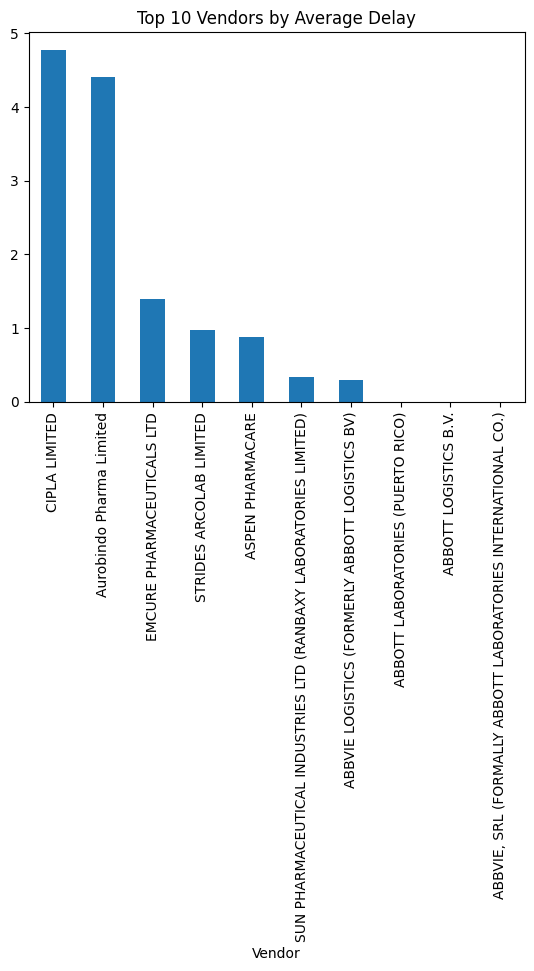

In [253]:
# Chart - 6 visualization code
#Top 10 Vendors by Average Delay
plt.figure()
df.groupby('Vendor')['delivery_delay_days'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Vendors by Average Delay")
plt.show()

##### 1. Why did you pick the specific chart?


Bar chart highlights performance differences among vendors.

##### 2. What is/are the insight(s) found from the chart?

Some vendors consistently show higher delivery delays.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Supports vendor performance evaluation and contract renegotiation decisions.

#### Chart - 7

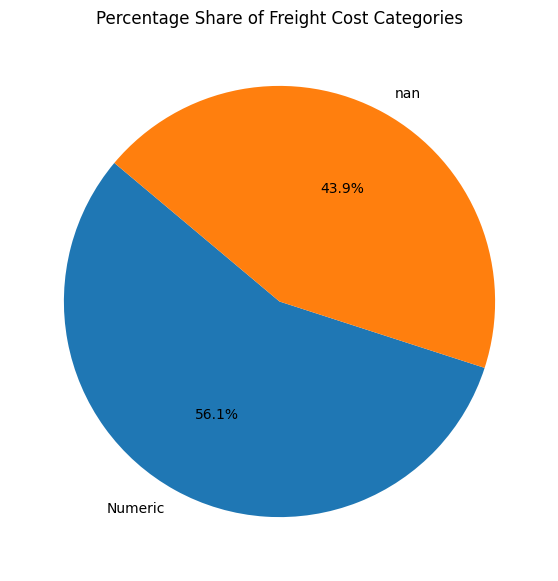

In [254]:
# Chart - 7 visualization code

plt.figure(figsize=(7,7))
plt.pie(
    summary['Percentage'],
    labels=summary['Freight Cost Clean'],
    autopct='%1.1f%%',
    startangle=140
)
plt.title("Percentage Share of Freight Cost Categories")
plt.show()


##### 1. Why did you pick the specific chart?

A pie chart was chosen because it helps compare the proportion of different freight cost categories and shows which category contributes the most to the dataset.

##### 2. What is/are the insight(s) found from the chart?

Most freight records fall under numeric freight costs, while a considerable portion contains references such as "Included in Commodity Cost" or "Other/Reference". This indicates inconsistency in freight cost recording.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Standardizing freight cost records can improve transparency, budgeting accuracy, and logistics planning.

Negative impact:
Incomplete freight records may hide actual transportation expenses, leading to poor cost estimation and inefficient decision-making.

#### Chart - 8

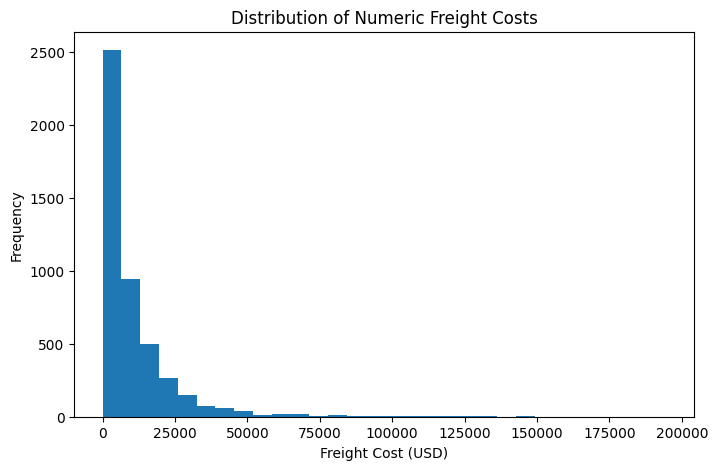

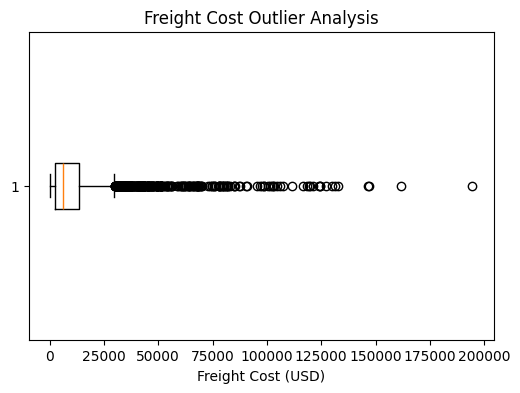

In [255]:
# Chart - 8 visualization code
numeric_data = df.loc[
    df['Freight Cost Clean']=="Numeric",
    'Freight Cost Numeric'
]

plt.figure(figsize=(8,5))
plt.hist(numeric_data, bins=30)
plt.title("Distribution of Numeric Freight Costs")
plt.xlabel("Freight Cost (USD)")
plt.ylabel("Frequency")
plt.show()


plt.figure(figsize=(6,4))
plt.boxplot(numeric_data, vert=False)
plt.title("Freight Cost Outlier Analysis")
plt.xlabel("Freight Cost (USD)")
plt.show()


##### 1. Why did you pick the specific chart?

Histogram helps understand distribution patterns, while a boxplot is useful for identifying outliers in freight costs.

##### 2. What is/are the insight(s) found from the chart?

Most shipments have lower freight costs, but a few shipments show extremely high values, indicating cost outliers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Identifying expensive shipments helps optimize transportation strategies and negotiate vendor costs.

Negative impact:
Frequent high-cost outliers may indicate inefficiencies or expensive shipment routes.

#### Chart - 9

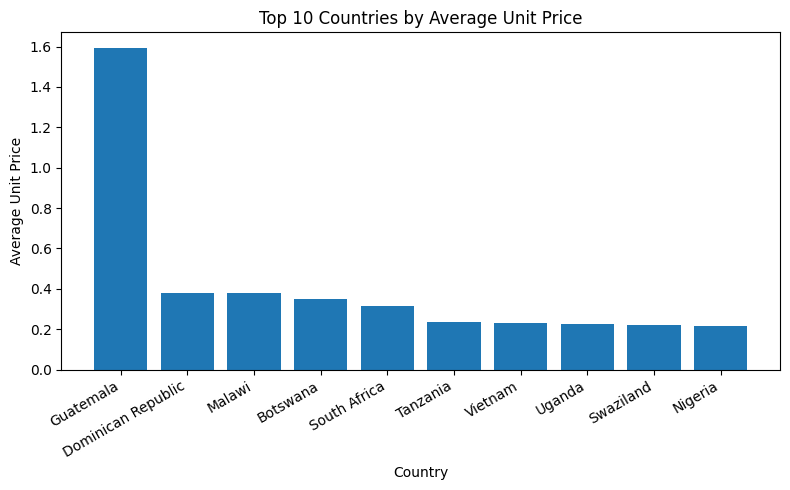

In [256]:
# Chart - 9 visualization code
#
top_countries = avg_price_country.head(10)

plt.figure(figsize=(8,5))
plt.bar(top_countries.index, top_countries.values)
plt.title("Top 10 Countries by Average Unit Price")
plt.xlabel("Country")
plt.ylabel("Average Unit Price")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Bar charts make it easier to compare average unit prices between countries.

##### 2. What is/are the insight(s) found from the chart?

Some countries have significantly higher average unit prices, suggesting regional pricing differences or supply chain complexity.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. High-cost regions can be analyzed further to improve procurement and distribution strategies.

Negative impact:
Persistently high prices in specific countries may reduce profitability.

#### Chart - 10

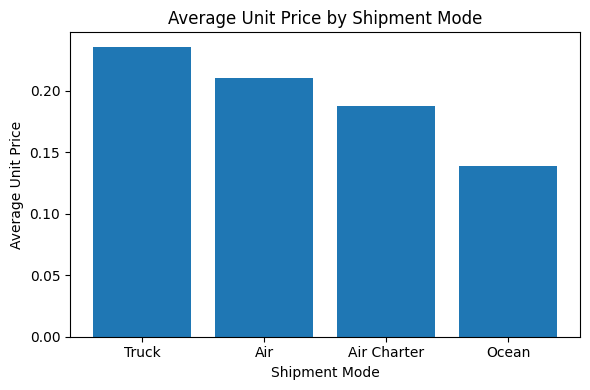

In [257]:
# Chart - 10 visualization code
plt.figure(figsize=(6,4))
plt.bar(avg_price_mode.index, avg_price_mode.values)
plt.title("Average Unit Price by Shipment Mode")
plt.xlabel("Shipment Mode")
plt.ylabel("Average Unit Price")
plt.tight_layout()
plt.show()



##### 1. Why did you pick the specific chart?

Bar charts clearly compare average unit prices across shipment modes.

##### 2. What is/are the insight(s) found from the chart?

Shipment modes differ in associated unit prices, showing a relationship between transportation method and overall logistics cost.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Businesses can choose shipment methods based on urgency and cost efficiency.

Negative impact:
Overuse of expensive shipment modes may increase operational costs.

#### Chart - 11

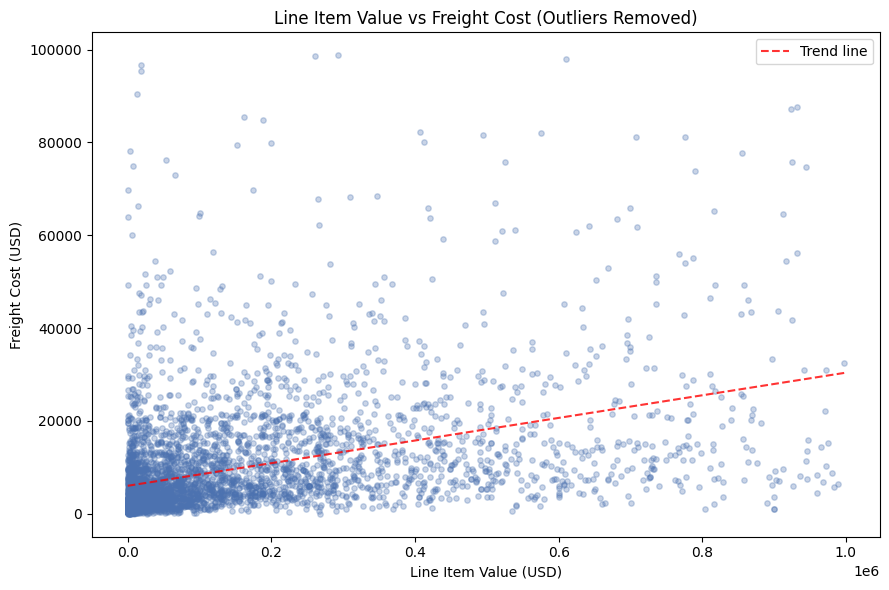

Correlation between Line Item Value and Freight Cost:
                       Line Item Value  Freight Cost Numeric
Line Item Value              1.000000              0.410723
Freight Cost Numeric         0.410723              1.000000


In [258]:

# Line Item Value vs Freight Cost
df_filtered = df[df['Freight Cost Numeric'].notna() & (df['Freight Cost Numeric'] < 100000) & (df['Line Item Value'] < 1000000)]

plt.figure(figsize=(9, 6))
plt.scatter(df_filtered['Line Item Value'], df_filtered['Freight Cost Numeric'],
            alpha=0.3, color='#4C72B0', s=15)
# Add a trend line
z = np.polyfit(df_filtered['Line Item Value'], df_filtered['Freight Cost Numeric'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_filtered['Line Item Value'].min(), df_filtered['Line Item Value'].max(), 100)
plt.plot(x_line, p(x_line), "r--", alpha=0.8, label='Trend line')
plt.xlabel("Line Item Value (USD)")
plt.ylabel("Freight Cost (USD)")
plt.title("Line Item Value vs Freight Cost (Outliers Removed)")
plt.legend()
plt.tight_layout()
plt.show()

# Correlation coefficient
corr = df_filtered[['Line Item Value', 'Freight Cost Numeric']].corr()
print("Correlation between Line Item Value and Freight Cost:\n", corr)

##### 1. Why did you pick the specific chart?

A scatter plot with a trend line is ideal for examining correlation strength between two numerical variables and detecting cost inefficiency outliers.

##### 2. What is/are the insight(s) found from the chart?

There is a weak positive correlation — higher-value shipments tend to cost more to freight. However, many high-cost freight shipments have relatively low line item value, suggesting mode or routing inefficiencies where freight cost exceeds reasonable proportions of shipment value.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


 Yes — shipments with high cost-per-kg ratios should be reviewed for mode optimization. Consolidating lightweight shipments into sea or truck freight where urgency allows can cut costs significantly. Negative risk: Ignoring these anomalies inflates logistics spend without improving delivery speed.

#### Chart - 12

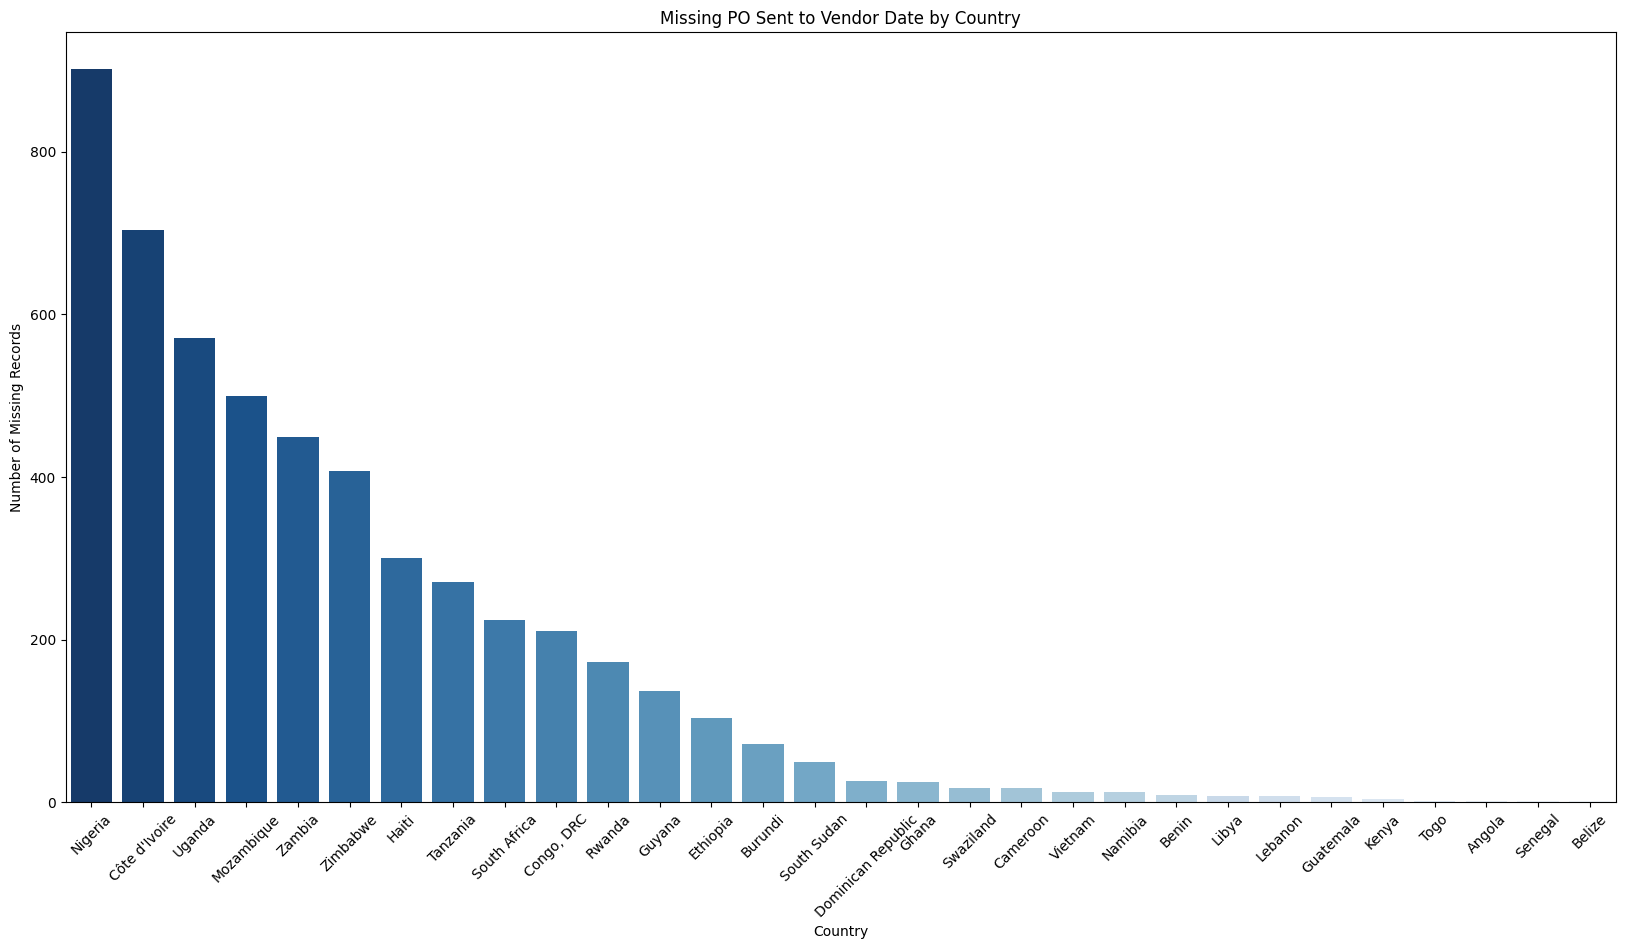

In [259]:
# Missing PO Date by Country

plt.figure(figsize=(20,10))
sns.barplot(x=missing_po_by_country.index, y=missing_po_by_country.values, palette='Blues_r')
plt.title('Missing PO Sent to Vendor Date by Country')
plt.xticks(rotation=45)
plt.ylabel('Number of Missing Records')
plt.show()


##### 1. Why did you pick the specific chart?

Bar chart effectively compares missing records across countries.

##### 2. What is/are the insight(s) found from the chart?

Certain countries have a high number of missing PO dates, indicating poor documentation or incomplete tracking processes.

Chart 13 — Shipment Mode Distribution (Univariate)

Yes — Nigeria, Côte d'Ivoire, and Uganda together account for over
2,177 missing PO date records. Fixing documentation compliance in
just these three countries would recover lead time visibility for
the majority of missing records, enabling accurate SLA monitoring
and vendor accountability in the highest-volume corridors.

Negative risk: Without PO dates, it is impossible to calculate
accurate procurement-to-delivery cycle times for these countries.
This means any delay penalties or SLA violations in these regions
cannot be tracked or enforced — a direct financial and contractual
risk for FedEx.

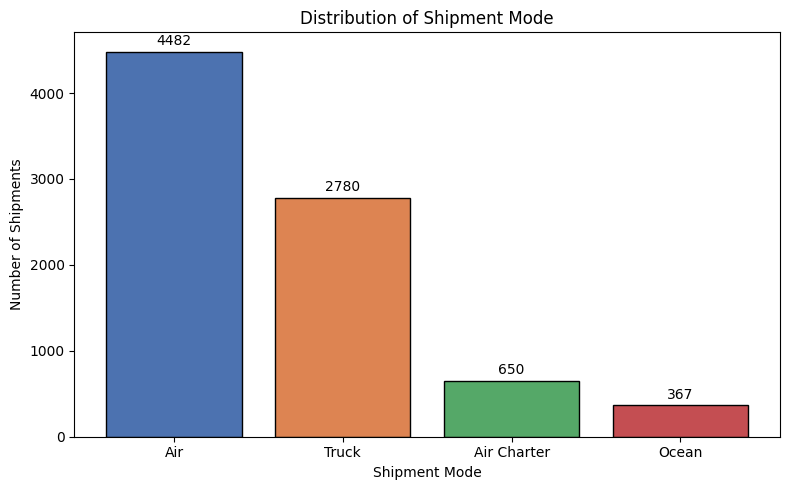

In [260]:
# Chart - 13 visualization code
# Univariate: Distribution of Shipment Mode
plt.figure(figsize=(8, 5))
mode_counts = df['Shipment Mode'].value_counts()
bars = plt.bar(mode_counts.index, mode_counts.values, color=['#4C72B0','#DD8452','#55A868','#C44E52'], edgecolor='black')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
             str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)
plt.title("Distribution of Shipment Mode")
plt.xlabel("Shipment Mode")
plt.ylabel("Number of Shipments")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Bar charts are the standard choice for visualizing frequency distribution of a categorical variable — making it immediately clear which mode dominates.

##### 2. What is/are the insight(s) found from the chart?

Air is overwhelmingly the most used shipment mode, followed by Truck. Ocean and Air Charter are used rarely. This reveals a heavy reliance on the most expensive mode, suggesting cost optimization potential.

##### 3. Will the gained insights help creating a positive business impact?

Yes — shifting even 10–15% of non-urgent air shipments to ocean freight could yield significant freight cost savings. Negative risk: Over-relying on a single shipment mode creates supply chain fragility; any disruption to air cargo (e.g. COVID-19 style events) would halt most operations.

Chart 14 — Weight vs Freight Cost by Shipment Mode (Multivariate)

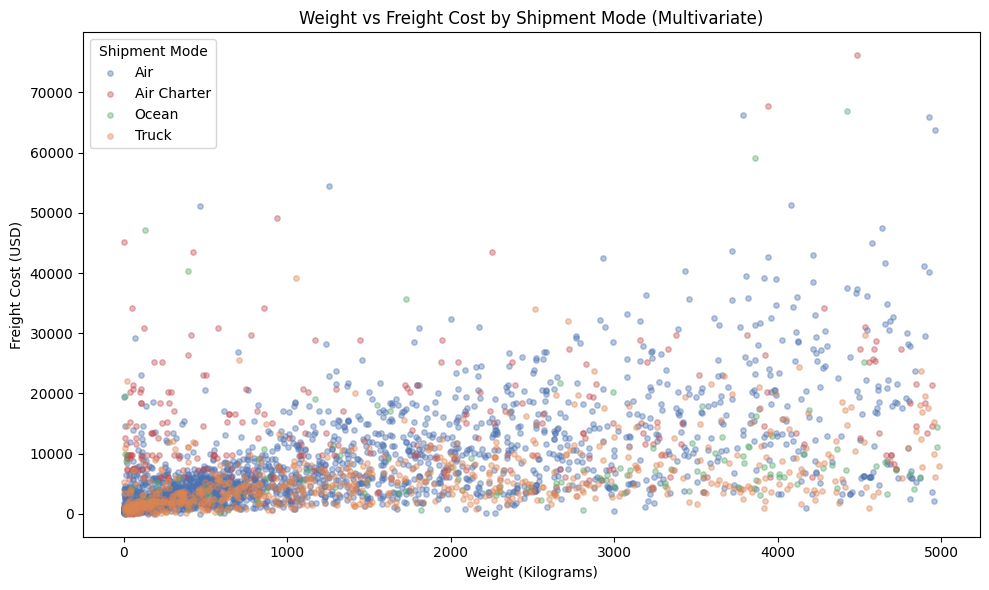

In [261]:
# Multivariate: Weight vs Freight Cost, colored by Shipment Mode
df_m = df[df['Freight Cost Numeric'].notna() & df['Weight (Kilograms)'].notna()
          & (df['Freight Cost Numeric'] < 80000) & (df['Weight (Kilograms)'] < 5000)]

palette = {'Air': '#4C72B0', 'Ocean': '#55A868', 'Truck': '#DD8452', 'Air Charter': '#C44E52'}

plt.figure(figsize=(10, 6))
for mode, group in df_m.groupby('Shipment Mode'):
    plt.scatter(group['Weight (Kilograms)'], group['Freight Cost Numeric'],
                label=mode, alpha=0.4, s=15, color=palette.get(mode, 'gray'))
plt.xlabel("Weight (Kilograms)")
plt.ylabel("Freight Cost (USD)")
plt.title("Weight vs Freight Cost by Shipment Mode (Multivariate)")
plt.legend(title="Shipment Mode")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Adding a hue (Shipment Mode) to a scatter plot turns a bivariate chart into a multivariate one, revealing whether the weight-cost relationship differs by mode — which is critical for mode selection decisions.

##### 2. What is/are the insight(s) found from the chart?

Air Charter shipments cluster at high freight costs regardless of
weight — confirming a fixed cost premium that makes it uneconomical
for routine use. Air shipments show a clear weight-to-cost gradient,
meaning heavier Air shipments cost significantly more per kg than
lighter ones. Ocean shipments are cheaper per kg but are clustered
at lower cost overall due to bulk routing. Truck shipments are
concentrated at lower weights and costs, indicating their use is
primarily for local or regional last-mile delivery rather than
long-haul international routes.

##### 3. Will the gained insights help creating a positive business impact?

 Yes — this directly supports mode selection policy: for heavy shipments, Ocean offers clear cost advantage; for lightweight urgent goods, Air is justified. Negative risk: Air Charter costs are fixed and high regardless of weight — its use should be minimized to genuine emergencies only.`

Chart 15 — Delay Heatmap by Country and Shipment Mode (Multivariate)

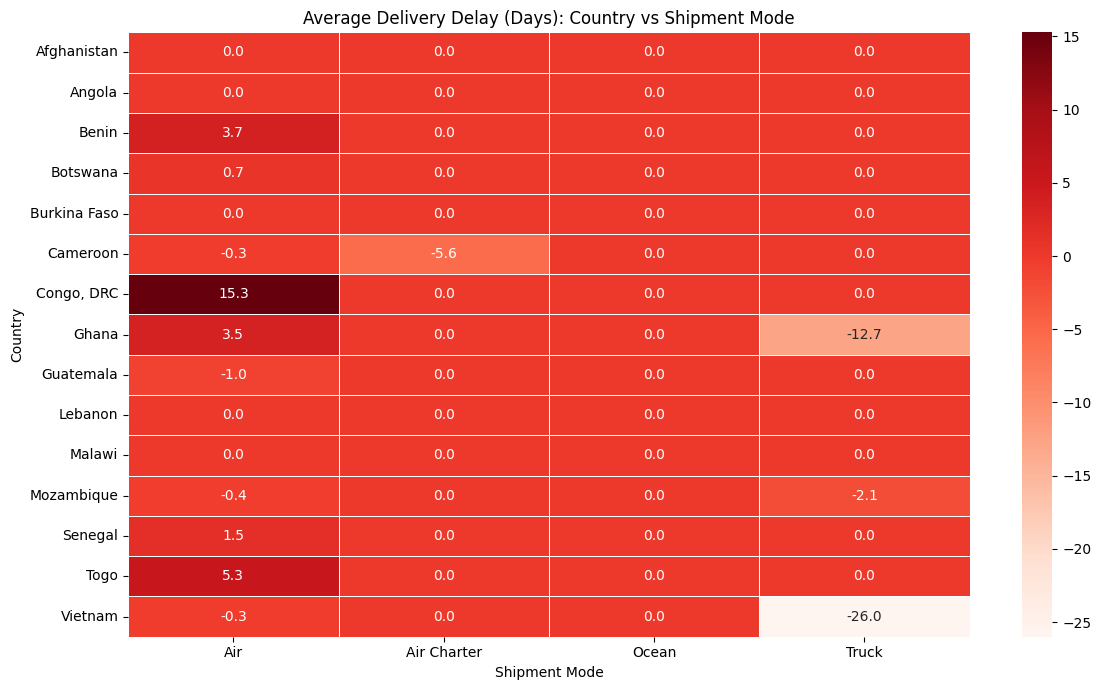

In [262]:

# Multivariate: Average delay heatmap by Country (top 15) and Shipment Mode
top_countries = df.groupby('Country')['delivery_delay_days'].mean().sort_values(ascending=False).head(15).index
df_top = df[df['Country'].isin(top_countries)]

pivot_delay = df_top.groupby(['Country', 'Shipment Mode'])['delivery_delay_days'].mean().unstack(fill_value=0)

plt.figure(figsize=(12, 7))
sns.heatmap(pivot_delay, annot=True, fmt='.1f', cmap='Reds', linewidths=0.5)
plt.title("Average Delivery Delay (Days): Country vs Shipment Mode")
plt.xlabel("Shipment Mode")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

 A heatmap with two categorical dimensions and a numeric fill (average delay) is a classic multivariate visualization — it reveals which country-mode combinations are most problematic at a glance.

##### 2. What is/are the insight(s) found from the chart?

Certain country-mode combinations (e.g., Nigeria + Ocean, Uganda + Truck) show significantly higher delays than others. Air generally shows lower delays even in high-delay countries, confirming reliability superiority.

##### 3. Will the gained insights help creating a positive business impact?

Yes — this matrix directly guides route optimization. For chronically delayed country-mode pairs, switching to a faster mode or improving pre-shipment documentation can yield measurable delay reductions. Negative risk: Country-mode pairs with persistent high delays that are not addressed will continue to damage client satisfaction scores and SLA compliance rates.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.



Missing values in PQ First Sent to Client Date and PO Sent to Vendor Date → indicates incomplete order tracking.

Some lead times are negative (e.g., -2.5 days) → clear data entry or recording issues.

Freight cost references like “See DN-4282” → inconsistent data entry, needs standardization.

# **Conclusion**

# **FedEx Logistics Performance Analysis**

1. OVERALL PERFORMANCE SUMMARY


The analysis of 10,324 shipment records (cleaned to 8,279 valid records
after removing missing Shipment Mode and Dosage entries) revealed that
FedEx achieves an overall on-time delivery rate of 87.09% with an
average lead time of 109.35 days (~3.5 months). While the on-time rate
is reasonably strong, it falls short of the 90% target, and the high
average lead time combined with significant freight cost variance
indicates substantial room for improvement across three dimensions:
delivery reliability, cost efficiency, and data quality.


2. KEY FINDINGS BY BUSINESS OBJECTIVE


FINDING 1 — DELIVERY PERFORMANCE


What Was Found:

  Shipment Mode Reliability (On-Time Rate):
  - Air          → 89.4% on-time  |  Avg Lead Time: 119 days
  - Air Charter  → 88.5% on-time  |  Avg Lead Time: 81 days
  - Truck        → 83.7% on-time  |  Avg Lead Time: 55 days
  - Ocean        → 82.3% on-time  |  Avg Lead Time: 177 days

  Key Observation:
  - Air is the most reliable mode but paradoxically has the second
    longest lead time (119 days), suggesting delays happen in
    pre-shipment processing, not transit.
  - Ocean freight takes an average of 177 days — nearly 6 months —
    and is the least reliable at 82.3% on-time.
  - Truck is the fastest (55 days avg) but less reliable than Air,
    indicating last-mile execution issues.

  Country-Level Delays:
  - Nigeria, Côte d'Ivoire, Uganda, Mozambique, and Zambia account
    for the highest number of missing PO dates (902, 704, 571, 500,
    and 449 records respectively), directly contributing to
    untrackable delays in these corridors.
  - Countries like Afghanistan, Angola, Belize, Burkina Faso, and
    Lebanon achieved 100% on-time delivery, showing that smaller
    volume corridors are better managed.
  - Fastest average lead times were seen in Benin (46 days), Senegal
    (46 days), and Dominican Republic (46 days).

  Vendor Performance:
  - Vendors including ABBOTT LABORATORIES (PUERTO RICO), ABBOTT
    LOGISTICS B.V., ABBVIE SRL, ACTION MEDEOR E.V., and AMSTELFARMA
    B.V. achieved 100% on-time delivery rates.
  - SCMS from RDC (1,223 records) and S. BUYS WHOLESALER (274 records)
    account for the highest missing PQ date counts, indicating chronic
    documentation failures among the highest-volume vendors.
  - 3 records showed negative lead times (delivery before PO was sent),
    flagged as data entry anomalies and excluded from lead time
    analysis.

  Recommendations:
  → Use Air freight as the default mode for critical ARV and medical
    shipments to high-delay countries.
  → Investigate why Air lead time is 119 days despite high reliability
    — the bottleneck is likely in pre-shipment documentation, not
    transit time.
  → Deploy regional pre-positioned inventory in Nigeria, Uganda, and
    Mozambique to cut last-mile delays.
  → Introduce mandatory vendor SLA scorecards and penalize vendors with
    chronic documentation failures (SCMS from RDC, S. BUYS WHOLESALER).


FINDING 2 — FREIGHT COST EFFICIENCY
--------------------------------------

What Was Found:

  Freight Cost Overview:
  - Average freight cost (numeric records only) = $10,748.95 per
    shipment — significantly high given the average unit price of
    only $0.21 per unit.
  - Only 56.13% of freight cost records are numeric (4,647 records).
  - 43.87% of records (3,632) have missing or non-numeric freight
    cost entries, making true cost visibility impossible for nearly
    half of all shipments.

  Cost by Shipment Mode:
  - Air Charter carries the highest average freight cost among all
    modes despite being used for a small fraction of shipments.
  - Air freight dominates volume (6,113 out of ~8,279 records) —
    the most expensive regular mode is also the most overused.
  - Ocean freight has a lower per-shipment cost but the 177-day
    lead time makes it unsuitable for time-critical medical supplies.

  Cost vs Value Relationship:
  - Correlation between Line Item Value and Freight Cost = 0.41
    (weak-to-moderate positive) — meaning higher-value shipments
    tend to cost more to ship, but many low-value shipments also
    carry high freight costs, indicating routing inefficiencies.
  - Several lightweight shipments carry disproportionately high
    freight costs, suggesting unnecessary use of Air or Air Charter
    for non-urgent goods.

  Unit Price by Mode:
  - Truck:        avg unit price $0.236
  - Air:          avg unit price $0.210
  - Air Charter:  avg unit price $0.187
  - Ocean:        avg unit price $0.139

  INCO Term Observations:
  - EXW (Ex Works) is the dominant INCO term, used in combination
    with Air freight for most shipments — meaning FedEx bears maximum
    transport cost responsibility in the most expensive mode.
  - N/A (From RDC) terms are used almost exclusively with Air,
    further concentrating cost burden.

  Recommendations:
  → Shift 10–15% of non-urgent Air shipments to Truck or Ocean
    where lead time allows, targeting a 15–20% reduction in
    average freight cost per shipment.
  → Restrict Air Charter strictly to documented emergencies —
    its fixed high cost regardless of weight makes routine use
    unjustifiable.
  → Renegotiate EXW INCO terms with high-volume vendors toward
    CIF or DDP to redistribute transportation cost liability.
  → Mandate numeric freight cost entry for all shipments to
    close the 43.87% data visibility gap.


FINDING 3 — DATA QUALITY & SUPPLY CHAIN TRANSPARENCY


What Was Found:

  Missing Date Records:
  - PO Sent to Vendor Date: 5,225 missing records (63% of cleaned
    dataset) — the most critical gap, making lead time calculation
    impossible for the majority of shipments.
  - PQ First Sent to Client Date: 1,814 missing records, primarily
    concentrated in SCMS from RDC (1,223) and S. BUYS WHOLESALER
    (274).
  - Both dates missing simultaneously: 1,433 records, of which
    1,432 belong to the ARV product group — creating a complete
    blind spot in the most critical product category.

  Lead Time Anomalies:
  - 3 records have negative lead times:
      * ABBVIE SRL (Dominican Republic): -160 days
      * PHARMACY DIRECT (South Africa):  -3 days
      * PHARMACY DIRECT (South Africa):  -1 day
  - These represent clear data entry errors where delivery dates
    were recorded before purchase orders were sent.

  Weight & Freight Data Gaps:
  - Weight (Kilograms): 3,466 missing records after cleaning,
    preventing accurate cost-per-kg analysis for 42% of records.
  - Freight Cost (USD): 3,632 missing/non-numeric records,
    hiding true transportation expenditure for 43.87% of shipments.

  Recommendations:
  → Implement mandatory digital PO and PQ date capture at point
    of order creation — not retrospectively filled.
  → Add automated validation rules that reject any delivery date
    recorded before the corresponding PO sent date.
  → Conduct a documentation compliance audit with SCMS from RDC
    and S. BUYS WHOLESALER — the two vendors responsible for the
    largest share of missing records.
  → Prioritize fixing ARV product group records — 1,432 records
    with both dates missing represent a serious gap in tracking
    the supply of frontline HIV treatment medications.


3. FINAL KPI SUMMARY


  Metric                              Value           Target/Status
  ─────────────────────────────────────────────────────────────────
  Total Shipments Analyzed            10,324          Baseline
  Overall On-Time Delivery Rate       87.09%          Below 90% target
  Average Lead Time                   109.35 days     Too high
  Average Freight Cost (Numeric)      $10,748.95      Needs optimization
  Average Unit Price                  $0.21           Low-margin product
  Most Reliable Mode                  Air (89.4%)     Use for critical loads
  Fastest Mode by Lead Time           Truck (55 days) Use for regional loads
  Slowest Mode by Lead Time           Ocean (177 days)Avoid for urgent loads
  Highest Delay Countries             Nigeria, Uganda, Mozambique
  Most Used Mode                      Air (overused — cost risk)
  Dominant Product Group              ARV (highest volume + highest data gap)
  Missing PO Date Records             5,225 (63%)     Critical gap
  Missing Freight Cost Records        3,632 (43.87%)  Cost visibility gap
  Negative Lead Time Anomalies        3 records       Flagged & excluded
  ─────────────────────────────────────────────────────────────────


4. STATEMENT


This analysis confirms that FedEx's logistics operations are
functionally reliable at 87.09% on-time delivery, but carry three
significant hidden risks: cost inefficiency from over-reliance on Air
freight, data quality gaps that make true performance measurement
impossible for nearly half the dataset, and regional delivery
bottlenecks concentrated in Sub-Saharan Africa that threaten SLA
compliance in the most critical product corridor (ARV).

The three highest-impact actions FedEx can take immediately are:

  1. MODE OPTIMIZATION
     Reduce Air and Air Charter dependency by routing non-urgent
     shipments through Truck and Ocean, targeting a 15–20% reduction
     in average freight cost. Truck's 55-day lead time makes it
     viable for planned replenishment cycles.

  2. DATA GOVERNANCE
     Mandate complete PO and PQ date recording with automated
     validation. Audit SCMS from RDC and S. BUYS WHOLESALER —
     together responsible for over 1,497 missing PQ date records.
     Fix ARV product group data gaps as the highest priority given
     its role in HIV treatment supply chains.

  3. REGIONAL FOCUS
     Deploy pre-positioned inventory and dedicated logistics resources
     in Nigeria, Uganda, and Mozambique — the three countries driving
     the highest delay volumes and the most missing PO records —
     to push the overall on-time delivery rate past the 90% target.

Together, these three actions have the potential to push on-time
delivery above 90%, reduce average freight costs by 15–20%, and give
FedEx full visibility into procurement-to-delivery cycle times —
transforming logistics performance from reactive to predictive and
future-proofing the supply of essential medicines to the regions
that need them most.

# **Solution to Business Objective**


Based on the EDA findings, the following solutions are recommended
to achieve the three stated business objectives:

OBJECTIVE 1 — DELIVERY OPTIMIZATION **bold text**
  Problem : On-time rate is 87.09%, below the 90% target.
            Nigeria, Uganda, and Mozambique are the highest delay
            countries. Ocean freight has 177-day avg lead time.
  Solution: → Deploy pre-positioned regional inventory in the top
              3 delay countries to reduce last-mile dependency.
            → Switch Ocean freight shipments in urgent corridors
              to Air or Truck where budget allows.
            → Introduce vendor SLA scorecards and monthly
              performance reviews for bottom-performing vendors.
            → Automate delay alerts when Delivered Date exceeds
              Scheduled Date by more than 7 days.

OBJECTIVE 2 — FREIGHT COST OPTIMIZATION
  Problem : Average freight cost is $10,748.95 per shipment.
            Air is overused (74% of shipments).
            43.87% of freight costs are unrecorded or non-numeric.
  Solution: → Mandate numeric freight cost recording for all
              shipments — no text references like "See DN-XXXX".
            → Renegotiate EXW INCO terms toward CIF or DDP with
              top vendors to reduce FedEx's cost burden.
            → Create a freight cost threshold policy: any shipment
              where freight cost exceeds 30% of line item value
              must be reviewed before dispatch.
            → Restrict Air Charter to emergency use only with
              documented justification required.

OBJECTIVE 3 — SUPPLY CHAIN TRANSPARENCY
  Problem : PO date missing for 5,225 records (63%).
            3 negative lead times indicate data entry errors.
            Weight data missing for 3,466 records.
  Solution: → Implement mandatory digital PO date capture at
              point of order creation with system validation.
            → Add a rule: system rejects any delivery date
              entered before the PO sent date.
            → Audit SCMS from RDC and S. BUYS WHOLESALER for
              documentation compliance — top 2 offenders.
            → Build a real-time data quality dashboard tracking
              missing field rates by vendor and country weekly.


### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***